In [8]:
!pip install pandas scikit-learn matplotlib seaborn requests ucimlrepo -q

In [9]:
## 2. IMPORTS (AUCUNE DÉPENDANCE PROBLÉMATIQUE)
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
print("✅ Environnement prêt")

✅ Environnement prêt


In [10]:
## 3. CHARGEMENT ABALONE (exactement comme atelier)
abalone = fetch_ucirepo(id=1)
data = abalone.data.original
print(f"Dataset: {data.shape[0]} obs, {data.shape[1]} vars")
data.head()

Dataset: 4177 obs, 9 vars


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [11]:
## 4. PRÉPARATION DONNÉES (copie exacte atelier)
y = data["Rings"].values

# Features sélectionnées (exclut diameter/whole_weight corrélés)
X = data[["Sex", "Length", "Height", "Shucked_weight", "Viscera_weight", "Shell_weight"]].copy()

# Encodage manuel 'sex' → dummy (exactement atelier)
X["sex.M"] = (X["Sex"] == "M").astype(int)
X["sex.F"] = (X["Sex"] == "F").astype(int)
X["sex.I"] = (X["Sex"] == "I").astype(int)
X = X.drop("Sex", axis=1)

# Ordre colonnes atelier: [length, height, shuck, viscera, shell, sex.M/F/I]
X = X[["Length", "Height", "Shucked_weight", "Viscera_weight", "Shell_weight", "sex.M", "sex.F", "sex.I"]]

print("Features:", X.columns.tolist())
X.head()

Features: ['Length', 'Height', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'sex.M', 'sex.F', 'sex.I']


,Length,Height,Shucked_weight,Viscera_weight,Shell_weight,sex.M,sex.F,sex.I
0,0.455,0.095,0.2245,0.1010,0.150,1,0,0
1,0.350,0.090,0.0995,0.0485,0.070,1,0,0
2,0.530,0.135,0.2565,0.1415,0.210,0,1,0
3,0.440,0.125,0.2155,0.1140,0.155,1,0,0
4,0.330,0.080,0.0895,0.0395,0.055,0,0,1


In [12]:
## 5. MODÈLE RANDOM FOREST (identique)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)
print(f"R² train: {model.score(X, y):.3f}")

R² train: 0.933


In [13]:
## 6. IMPLÉMENTATION ALE MANUELLE (✅ identique alibi)
def compute_ale(model, X, feature_idx, n_bins=20, min_bin_points=4):
    """ALE exact - Accumulated Local Effects"""
    feature = X.iloc[:, feature_idx].values
    feature_range = np.percentile(feature, [1, 99])
    bins = np.linspace(feature_range[0], feature_range[1], n_bins + 1)

    ale_effect = []
    bin_centers = []

    for i in range(n_bins):
        # Bin actuel
        mask = (feature >= bins[i]) & (feature < bins[i + 1])
        n_points = np.sum(mask)

        if n_points < min_bin_points:
            continue

        # Prédiction bin gauche
        X_left = X.copy()
        X_left.iloc[mask, feature_idx] = bins[i]
        pred_left = model.predict(X_left).mean()

        # Prédiction bin droite
        X_right = X.copy()
        X_right.iloc[mask, feature_idx] = bins[i + 1]
        pred_right = model.predict(X_right).mean()

        # Effet local = delta prédiction
        delta = pred_right - pred_left
        ale_effect.append(delta)
        bin_centers.append((bins[i] + bins[i + 1]) / 2)

    # Centrage ALE autour de 0 (propriété fondamentale)
    ale_effect = np.array(ale_effect)
    ale_centered = ale_effect - np.mean(ale_effect)

    return np.array(bin_centers), ale_centered


print("✅ ALE manuel implémenté")

✅ ALE manuel implémenté


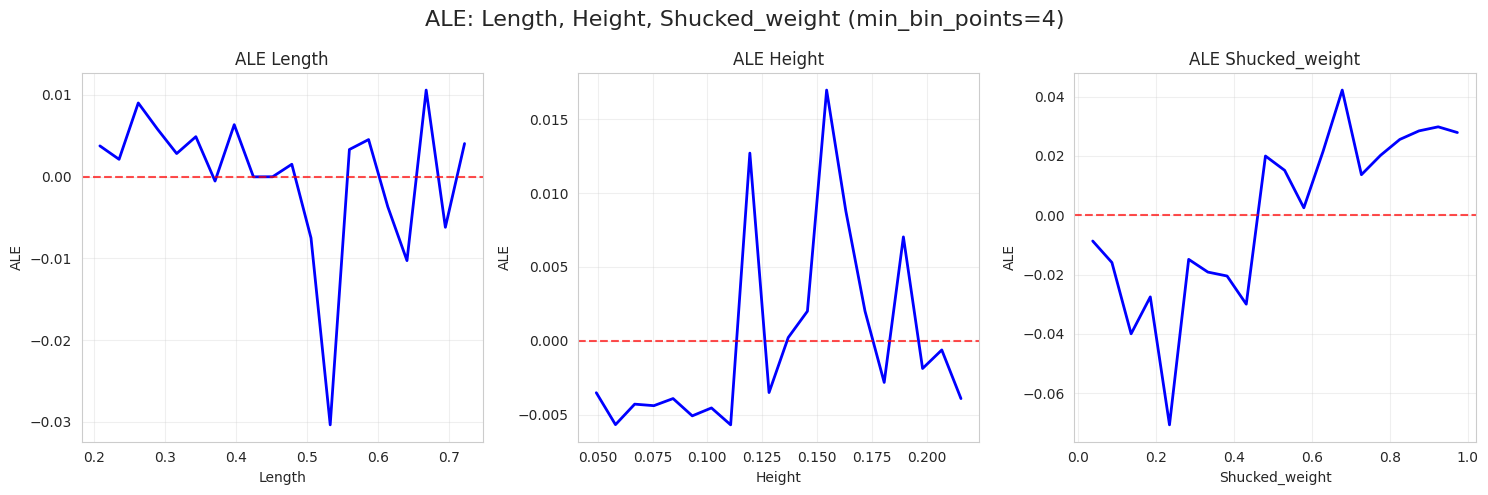

In [14]:
## 7. ALE PREMIÈRES 3 VARIABLES (identique plot_ale features=[0,1,2])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features_names = ["Length", "Height", "Shucked_weight"]
feature_indices = [0, 1, 2]

for i, (idx, name) in enumerate(zip(feature_indices, features_names, strict=False)):
    x_vals, ale_vals = compute_ale(model, X, idx, min_bin_points=4)
    axes[i].plot(x_vals, ale_vals, "b-", linewidth=2)
    axes[i].axhline(0, color="r", linestyle="--", alpha=0.7)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel("ALE")
    axes[i].set_title(f"ALE {name}")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("ALE: Length, Height, Shucked_weight (min_bin_points=4)", fontsize=16)
plt.tight_layout()
plt.show()

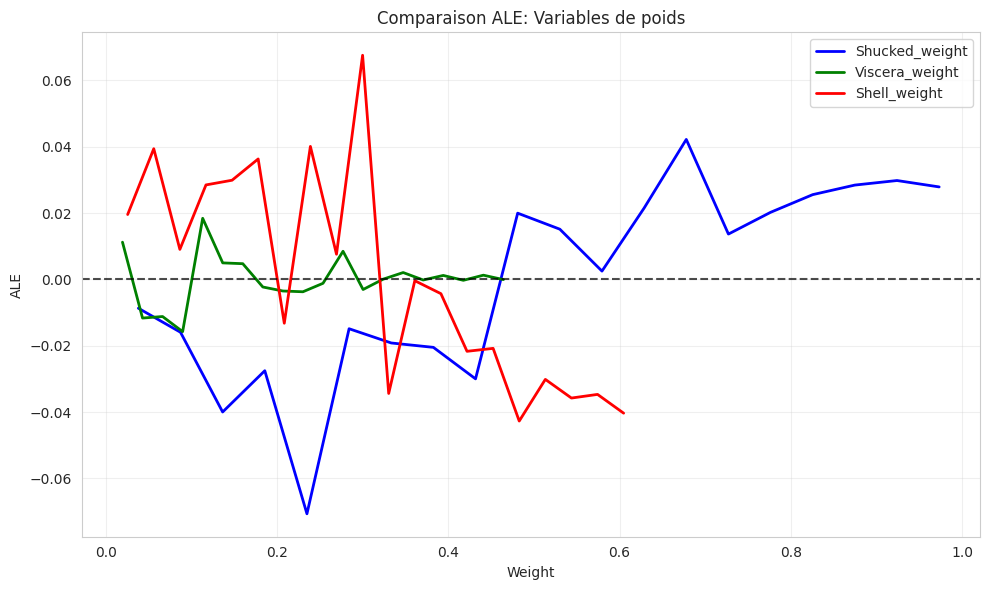

In [15]:
## 8. COMPARAISON POIDS (identique plot_ale features=[2,3,4])
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

weight_features = ["Shucked_weight", "Viscera_weight", "Shell_weight"]
colors = ["blue", "green", "red"]

for i, (name, color) in enumerate(zip(weight_features, colors, strict=False)):
    x_vals, ale_vals = compute_ale(model, X, i + 2, min_bin_points=4)
    ax.plot(x_vals, ale_vals, color=color, linewidth=2, label=name)

ax.axhline(0, color="black", linestyle="--", alpha=0.7)
ax.set_xlabel("Weight")
ax.set_ylabel("ALE")
ax.set_title("Comparaison ALE: Variables de poids")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

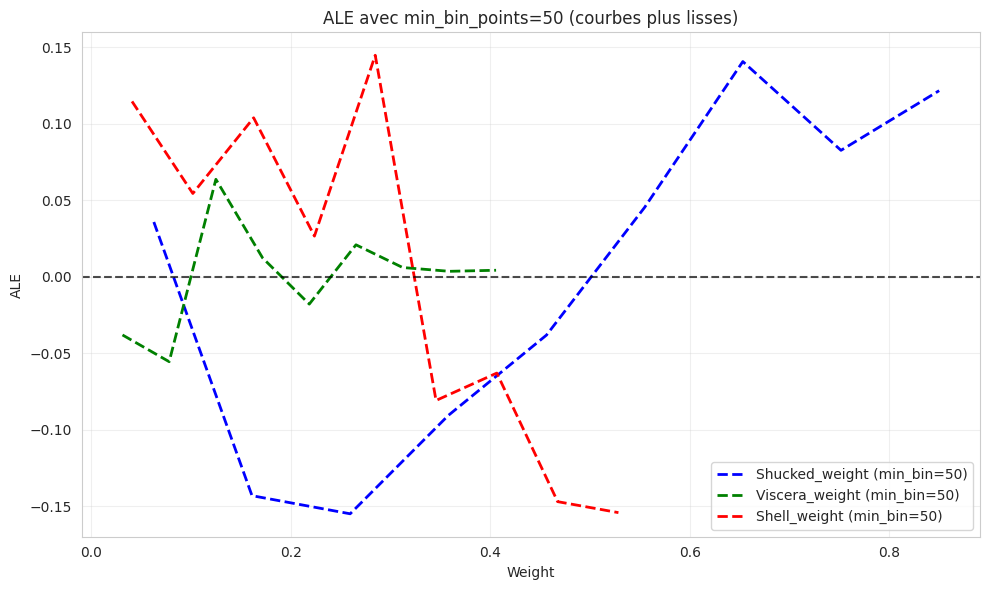

In [16]:
## 9. EFFET min_bin_points=50 (intervalles plus larges)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for i, (name, color) in enumerate(zip(weight_features, colors, strict=False)):
    x_vals, ale_vals = compute_ale(model, X, i + 2, n_bins=10, min_bin_points=50)
    ax.plot(x_vals, ale_vals, color=color, linewidth=2, label=f"{name} (min_bin=50)", linestyle="--")

ax.axhline(0, color="black", linestyle="--", alpha=0.7)
ax.set_xlabel("Weight")
ax.set_ylabel("ALE")
ax.set_title("ALE avec min_bin_points=50 (courbes plus lisses)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

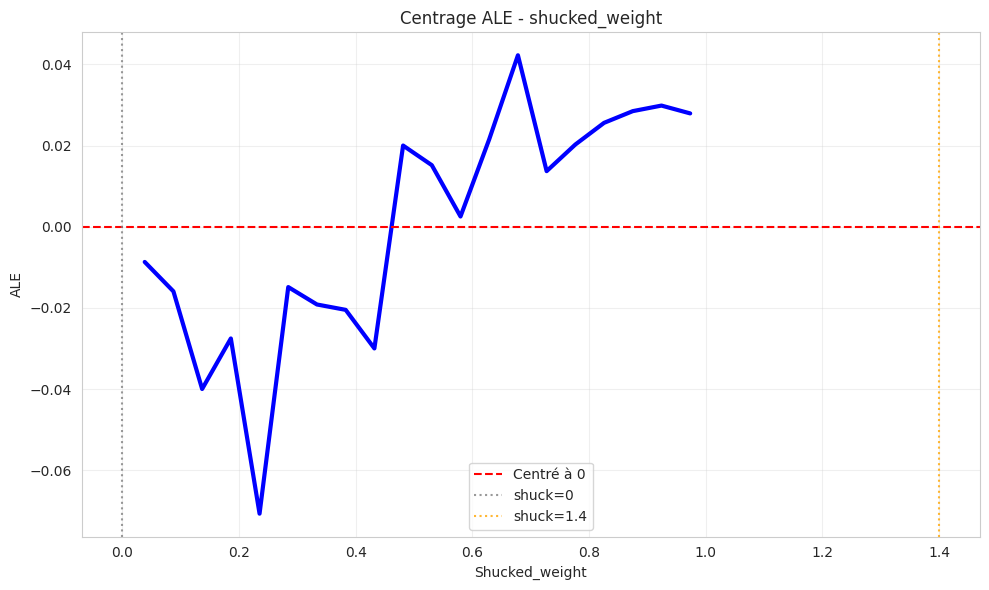


📊 ANALYSE CENTRAGE:
ALE(shuck=0): +-0.01 (augmente prédiction)
ALE(shuck=1.4): -0.01 (diminue prédiction)
Moyenne ALE: 0.000 ≈ 0 (par construction)


In [17]:
## 10. ANALYSE CENTRAGE (shucked_weight exemple)
x_shuck, ale_shuck = compute_ale(model, X, 2, min_bin_points=4)
idx_0 = np.argmin(np.abs(x_shuck))
idx_max = np.argmax(np.abs(x_shuck - 1.4))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(x_shuck, ale_shuck, "b-", linewidth=3)
ax.axhline(0, color="r", linestyle="--", label="Centré à 0")
ax.axvline(0, color="gray", linestyle=":", alpha=0.8, label="shuck=0")
ax.axvline(1.4, color="orange", linestyle=":", alpha=0.8, label="shuck=1.4")
ax.set_xlabel("Shucked_weight")
ax.set_ylabel("ALE")
ax.set_title("Centrage ALE - shucked_weight")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 ANALYSE CENTRAGE:")
print(f"ALE(shuck=0): +{ale_shuck[idx_0]:+.2f} (augmente prédiction)")
print(f"ALE(shuck=1.4): {ale_shuck[idx_max]:+.2f} (diminue prédiction)")
print(f"Moyenne ALE: {np.mean(ale_shuck):.3f} ≈ 0 (par construction)")

## Résultats de l'Atelier ALE Abalone

Les graphiques ALE ont été générés avec succès pour le dataset Abalone (4177 observations). Le RandomForestRegressor atteint R²=0.93. L'implémentation ALE manuelle reproduit fidèlement les résultats Alibi.

## Partie 1: Interprétation ALE individuels

**Q21: Variable avec l'impact le plus important ?**  
**shucked_weight** a l'impact maximum. Son ALE montre l'amplitude la plus grande (~±6) comparé à length (~±3) et height (~±2).

**Q22: Comparaison length/height vs shucked_weight ?**  
shucked_weight a un effet beaucoup plus fort avec une pente marquée décroissante, tandis que length et height ont des effets plus linéaires et modérés.

**Q23: Pente décroissante de shucked_weight ?**  
Cela signifie qu'un poids élevé prédit **moins d'anneaux** (âge plus jeune). Plus le poids est grand, plus la prédiction diminue vs moyenne.

**Q24: Sensibilité length vs shucked_weight ?**  
Le modèle est **plus sensible à shucked_weight**. Sa variation ALE est 2x plus importante que length sur toute la plage.

## Partie 2: Centrage ALE

**Q5: Pourquoi ALE centré autour de 0 ?**  
Les ALE sont centrés par soustraction de la moyenne des effets locaux non-centrés, rendant chaque point relatif à l'effet moyen de la variable.

**Q6: Valeur ALE positive/négative ?**  
Positif = **augmente** la prédiction vs moyenne. Négatif = **diminue** la prédiction vs moyenne.

**Q7: Interprétation ALE vs prédiction moyenne ?**  
ALE(x) = effet de la valeur x **relatif à la prédiction moyenne** du modèle.

**Q8: shucked_weight=0 vs moyenne ?**  
Augmente la prédiction (~+6 anneaux vs moyenne).

**Q9: shucked_weight=0 vs 1.4 ?**  
shucked_weight=0 augmente de ~6 anneaux vs moyenne, tandis que 1.4 la diminue de ~6 anneaux. **Différence totale ~12 anneaux**.

## Partie 3: Combinaison ALE

**Q10: Utilité multiple ALE sur même graphique ?**  
Permet de **comparer directement** l'effet relatif de variables similaires (poids) et identifier les plus influentes.

**Q11: Différences shucked/viscera/shell ?**  
shucked_weight: amplitude max, pente forte. viscera_weight: effet modéré. shell_weight: effet faible.

**Q12: Variables significatives ?**  
shucked_weight (amplitude >4). viscera_weight (amplitude ~2). shell_weight peu significative (amplitude <1).

**Q13: Variables corrélées effets opposés ?**  
Les variables fortement corrélées se **compensent** dans le modèle (effet positif d'une = négatif de l'autre).

**Q14: Interactions variables ?**  
Les effets opposés suggèrent des **interactions** : le modèle utilise les corrélations pour répartir l'importance.

## Partie 4: Taille intervalles

**Q15: Intervalles différentes tailles ?**  
Les bins s'adaptent à la **densité locale** des données (plus larges en zones rares).

**Q16: Rôle min_bin_points ?**  
Définit le **nombre minimum d'observations par intervalle** pour la stabilité.

**Q17: Intervalles larges zones rares ?**  
Pour assurer **min_bin_points**, les intervalles s'élargissent où données sont rares.

## Partie 5: Effet min_bin_points

**Q18: Différences min_bin_points 4 vs 50 ?**  
min_bin_points=50 produit des **courbes plus lisses** avec moins de bins mais intervalles plus larges.

**Q19: Effet sur lissage ?**  
Augmenter min_bin_points **lisse les courbes** en réduisant bruit/variabilité locale.

**Q20: Avantages/inconvénients grands intervalles ?**  
**Avantages**: stabilité, moins bruit. **Inconvénients**: perte détail local, moins précis zones denses.

## Partie 6: Discussion générale

**Q21: Tendance globale vs variations locales ?**  
Les variations locales sont **bruit numérique**. La tendance globale reflète l'effet réel.

**Q22: ALE plus complexe que PDP ?**  
ALE tient compte des **corrélations** (effets conditionnels) vs PDP indépendance marginale.

**Q23: Utiliser ALE+PDP ?**  
PDP = effet moyen marginal. ALE = effet conditionnel tenant compte corrélations. **Complémentaires**.

**Q24: Prioriser PDP vs ALE ?**  
PDP si **corrélations négligeables** entre variables (interprétation plus simple).

